In [2]:
# Code for Figures 1 and 2 in Katajisto, K., & La Mela, M. (2026). Uncontested Transnational Identity: The Activation,
# Strengthening and Superiority of Nordic Identity in Finland’s EU Debate of the 1990s. Scandinavian Journal of History.

# Data: ParliamentSampo speech dataset (CSV), 1980-2005. Linked Data Finland, www.ldf.fi, accessed in May 2026
# Place the CSV files for 1980-2005 in the subdirectory ./speeches-1980-2005/
# Requirements: Python 3, pandas, matplotlib
# Script created assisted with Claude Opus 5.5

In [4]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


In [6]:
# Read csv files with speeches, source: www.ldf.fi

list_df = []

list_files = glob.glob("./speeches-1980-2005/*.csv")

for file in list_files:
    print(file)
    df = pd.read_csv(file, index_col=None, header=0, sep=",", encoding="utf-8", on_bad_lines="skip")
    list_df.append(df)

df = pd.concat(list_df, axis=0, ignore_index=True)

./speeches-1980-2005/speeches_1984.csv
./speeches-1980-2005/speeches_1990.csv
./speeches-1980-2005/speeches_1991.csv
./speeches-1980-2005/speeches_1985.csv
./speeches-1980-2005/speeches_1993.csv
./speeches-1980-2005/speeches_1987.csv
./speeches-1980-2005/speeches_1986.csv
./speeches-1980-2005/speeches_1992.csv
./speeches-1980-2005/speeches_1996.csv
./speeches-1980-2005/speeches_1982.csv
./speeches-1980-2005/speeches_1983.csv
./speeches-1980-2005/speeches_1997.csv
./speeches-1980-2005/speeches_1981.csv
./speeches-1980-2005/speeches_1995.csv
./speeches-1980-2005/speeches_1994.csv
./speeches-1980-2005/speeches_1980.csv
./speeches-1980-2005/speeches_2001.csv
./speeches-1980-2005/speeches_2000.csv
./speeches-1980-2005/speeches_2002.csv
./speeches-1980-2005/speeches_2003.csv
./speeches-1980-2005/speeches_2004.csv
./speeches-1980-2005/speeches_2005.csv
./speeches-1980-2005/speeches_1999.csv
./speeches-1980-2005/speeches_1998.csv
./speeches-1980-2005/speeches_1988.csv
./speeches-1980-2005/spee

In [8]:
# Remove the speeches by the Speakers
roles_remove = [
    "Puhemies",
    "Ensimmäinen varapuhemies",
    "Toinen varapuhemies",
    "Ikäpuhemies",
    "varapuhemies",
]

df = df[~df["role"].isin(roles_remove)].copy()

# Confirm the speech year
df["year"] = pd.to_datetime(df["date"], errors="coerce").dt.year
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)


In [10]:
# We extract the keywords:
# Europe, Nordic broad; Countries only capital initial (lowercase can be language)

patterns = {
    "Europe ([Ee]uroop*)": r"\b[Ee]uroop\w*",
    "Nordic ([Pp]ohjoism*)": r"\b[Pp]ohjoism\w*",
    "Sweden (Ruotsi*)": r"\bRuotsi\w*",
    "Norway (Norja*)": r"\bNorja\w*",
    "Denmark (Tanska*)": r"\bTanska\w*",
    "Iceland (Islan*)": r"\bIslan\w*",
}

# True if the speech mentions the keyword at least once
for term, pat in patterns.items():
    df[term] = df["content"].str.contains(pat, regex=True, na=False)


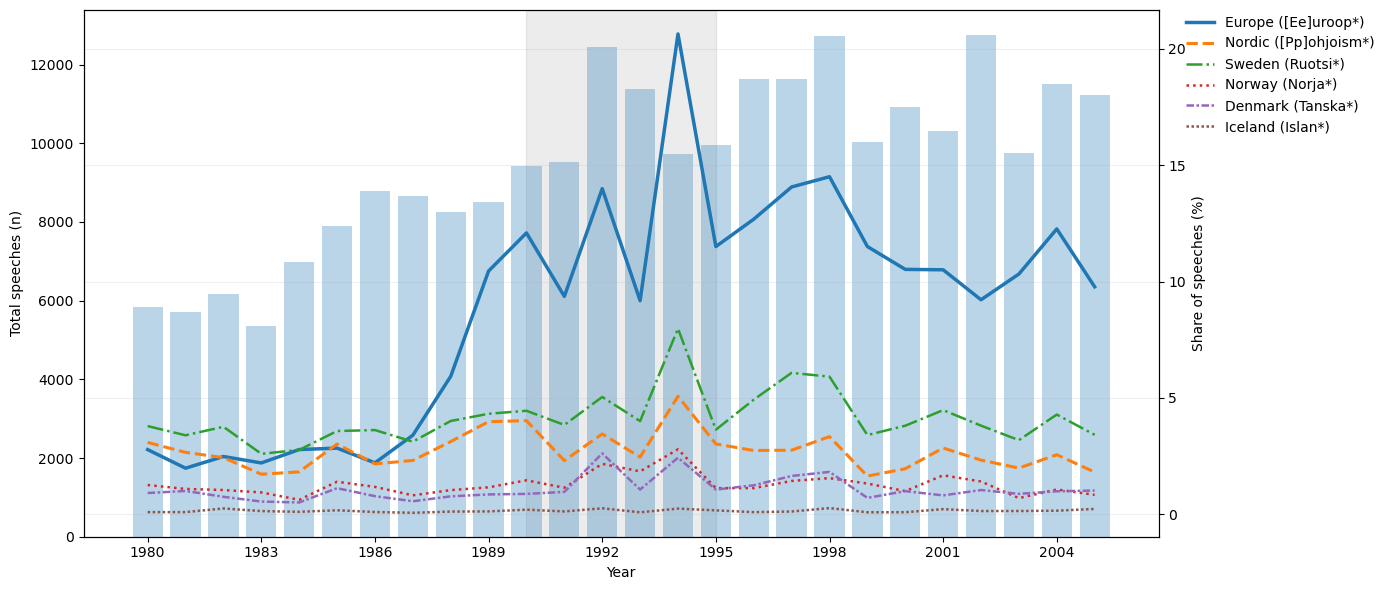

In [11]:
# Figure 1: Speeches per year (bars) and share of speeches with a keyword (lines)

# Yearly counts
yearly = df.groupby("year").agg(total_speeches=("content", "size"))

for term in patterns.keys():
    yearly[term] = df.groupby("year")[term].sum()

# Shares (%)
for term in patterns.keys():
    yearly[term] = yearly[term] / yearly["total_speeches"] * 100

yearly = yearly.reset_index()

# Plotting
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bars: total speeches
ax1.bar(yearly["year"], yearly["total_speeches"], alpha=0.30, zorder=1)
ax1.set_xlabel("Year")
ax1.set_ylabel("Total speeches (n)")
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# Highlight EC/EU debate period (1990–1995)
ax1.axvspan(1990, 1995, color="grey", alpha=0.15, zorder=0)

# Lines: shares (%)
ax2 = ax1.twinx()
ax2.set_ylabel("Share of speeches (%)")
ax2.grid(axis="y", alpha=0.2)

line_styles = {
    "Europe ([Ee]uroop*)": dict(linestyle="-",  linewidth=2.5),
    "Nordic ([Pp]ohjoism*)": dict(linestyle="--", linewidth=2.2),
    "Sweden (Ruotsi*)": dict(linestyle="-.", linewidth=1.8),
    "Norway (Norja*)": dict(linestyle=":",  linewidth=1.8),
    "Denmark (Tanska*)": dict(linestyle=(0, (3, 1, 1, 1)), linewidth=1.8),
    "Iceland (Islan*)": dict(linestyle=(0, (1, 1)), linewidth=1.8),
}

for term in patterns.keys():
    ax2.plot(yearly["year"], yearly[term], label=term, **line_styles[term])

# Legend:
ax2.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0, frameon=False)

plt.tight_layout()
plt.show()


In [13]:
# Figure 2: Nordic and Sweden mentions in session topics with and without Europe

# Clean the session topic so the same agenda item is grouped together
df["topic"] = (
    df["topic"]
    .fillna("")
    .astype(str)
    .str.split(">>>").str[0]
    .str.replace(r"^\d+\)", "", regex=True)
    .str.strip()
)

# Counts per session topic and year
topic_counts = df.groupby(["year", "topic"], as_index=False).agg(
    europe_speeches=("Europe ([Ee]uroop*)", "sum"),
    nordic_speeches=("Nordic ([Pp]ohjoism*)", "sum"),
    sweden_speeches=("Sweden (Ruotsi*)", "sum"),
)

# Session topics with three or more Europe speeches and zero Europe speeches
topic_counts["europe_topic"] = topic_counts["europe_speeches"] >= 3
topic_counts["non_europe_topic"] = topic_counts["europe_speeches"] == 0

# Session topics where Nordic, Sweden is mentioned in one speech at least
topic_counts["nordic_mentioned"] = topic_counts["nordic_speeches"] > 0
topic_counts["sweden_mentioned"] = topic_counts["sweden_speeches"] > 0

# Nordic, Sweden mentioned in Europe topics vs. non-Europe topics
topic_counts["nordic_in_europe"] = topic_counts["nordic_mentioned"] & topic_counts["europe_topic"]
topic_counts["nordic_in_non_europe"] = topic_counts["nordic_mentioned"] & topic_counts["non_europe_topic"]
topic_counts["sweden_in_europe"] = topic_counts["sweden_mentioned"] & topic_counts["europe_topic"]
topic_counts["sweden_in_non_europe"] = topic_counts["sweden_mentioned"] & topic_counts["non_europe_topic"]

# Calculate yearly counts (number of session topics)
yearly2 = topic_counts.groupby("year", as_index=False)[
    ["nordic_in_europe", "nordic_in_non_europe", "sweden_in_europe", "sweden_in_non_europe"]].sum()


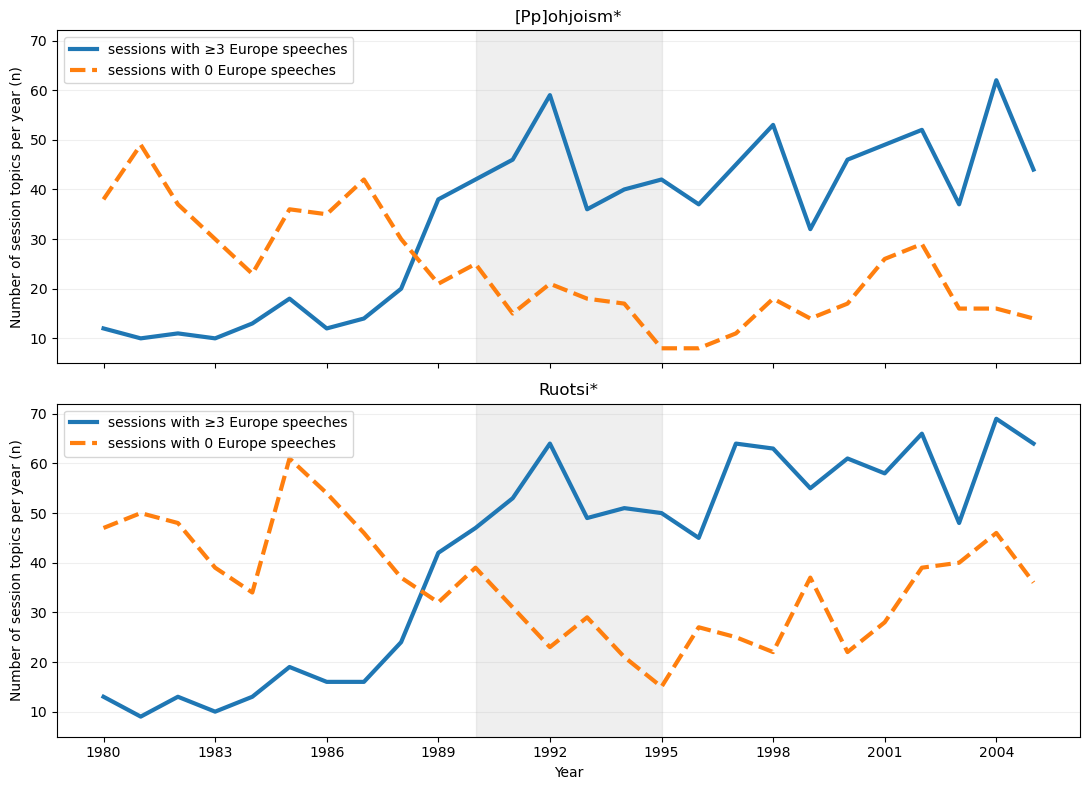

In [14]:
# Plotting

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, sharey=True)

# "Nordic" lines
axes[0].plot(yearly2["year"], yearly2["nordic_in_europe"], linewidth=3,
             label="sessions with ≥3 Europe speeches")
axes[0].plot(yearly2["year"], yearly2["nordic_in_non_europe"], linestyle="--", linewidth=3,
             label="sessions with 0 Europe speeches")
axes[0].set_title("[Pp]ohjoism*")

# "Sweden" lines
axes[1].plot(yearly2["year"], yearly2["sweden_in_europe"], linewidth=3,
             label="sessions with ≥3 Europe speeches")
axes[1].plot(yearly2["year"], yearly2["sweden_in_non_europe"], linestyle="--", linewidth=3,
             label="sessions with 0 Europe speeches")
axes[1].set_title("Ruotsi*")
axes[1].set_xlabel("Year")

# Axes, grid, and EC/EU debate period (1990–1995)
for ax in axes:
    ax.set_ylabel("Number of session topics per year (n)")
    ax.grid(axis="y", alpha=0.2)
    ax.axvspan(1990, 1995, color="grey", alpha=0.12)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend()

plt.tight_layout()
plt.show()